# ML Forecasting Experiment: Hard Labels vs. Soft Labels (Poisson-Binomial)

## Experiment Overview

This notebook investigates whether the Poisson-Binomial (PB) probabilities generated
from **observed shot xG data** can serve as richer training labels for ML-based
pre-match outcome forecasting models.

### Research Question
Can training a predictive model on xG-derived (post-match) probability estimates —
rather than binary win/draw/loss outcomes — improve the model's forecasting accuracy
for future matches?

### Design

| | Hard Labels | Soft Labels |
|---|---|---|
| **Training target** | Binary outcome (home win / draw / away win) | Poisson-Binomial outcome probabilities |
| **Test evaluation** | Actual match outcomes | Actual match outcomes |

Two model families are compared:
- **XGBoost** (gradient-boosted trees)
- **Logistic Regression** (linear softmax model)

Each is trained once with hard labels and once with soft (PB) labels — four models total,
plus Bet365 pre-match odds as an external benchmark.

### Features
Team identity (ordinal) + rolling averages of the last 5 matches for each team:
goals scored/conceded, xG produced/conceded, shots taken/conceded.

### Temporal Split
First 50% of matchweeks per league → **training set**  
Last 50% of matchweeks per league → **test set** (evaluation only)

## 1. Imports & Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(".").resolve()
sys.path.insert(0, str(NOTEBOOK_DIR / "../../modules"))

from evaluation import (
    compute_scoring_rules,
    bootstrap_outcome_metrics,
    plot_calibration_curves,
    plot_scoring_comparison,
)

FIGURES_DIR = NOTEBOOK_DIR / "figures"
OUTPUT_DIR  = NOTEBOOK_DIR / "output"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_DIR      = NOTEBOOK_DIR / "../../../data"
INPUT_DIR     = DATA_DIR / "input_data"
PROB_DIR      = DATA_DIR / "predicted_probabilities"
SUPP_OUT_DIR  = NOTEBOOK_DIR / "../output"

# ── Constants ─────────────────────────────────────────────────────────────────
LEAGUES = ["epl", "bundesliga", "laliga", "seriea", "ligue1"]

# Matchweek cutoff for 50/50 temporal split (weeks 1..cutoff = train)
LEAGUE_TRAIN_CUTOFF = {
    "epl": 19, "bundesliga": 17, "laliga": 19,
    "seriea": 19, "ligue1": 19,
}

STAT_COLS  = ["gs", "gc", "xgp", "xgc", "shots", "shots_c"]
STAT_NAMES = ["goals_scored", "goals_conceded", "xg_produced",
              "xg_conceded", "shots", "shots_conceded"]
ROLLING_COLS = [f"{c}_r" for c in STAT_COLS]

OUTCOME_MAP = {"home_win": 0, "draw": 1, "away_win": 2}
SEED = 42

print("Setup complete. Figures →", FIGURES_DIR)

Setup complete. Figures → /home/max/drive/projects/4_forecasting-polynomial-multiplication/data-analysis/supplementary-material/ml_forecasting/figures


## 2. Data Loading

In [2]:
# ── Load match input data ─────────────────────────────────────────────────────
all_matches = []
for league in LEAGUES:
    df = pd.read_parquet(INPUT_DIR / f"{league}_1516.parquet")
    df["league"] = league
    all_matches.append(df)
matches = pd.concat(all_matches, ignore_index=True)
matches["match_date"] = pd.to_datetime(matches["match_date"])
matches = matches.sort_values(["league", "match_date", "match_id"]).reset_index(drop=True)

print(f"Loaded {len(matches)} matches")
matches.groupby("competition_name").size().rename("matches").to_frame()

Loaded 1823 matches


,matches
competition_name,
England - Premier League,380
France - Ligue 1,377
Germany - 1. Bundesliga,306
Italy - Serie A,380
Spain - La Liga,380


In [3]:
# ── Load Poisson-Binomial probabilities (soft labels) ─────────────────────────
pb_list = []
for league in LEAGUES:
    df = pd.read_parquet(PROB_DIR / f"{league}_1516_poisson_binomial_outcomes.parquet")
    pb_list.append(df[["match_id", "actual_outcome", "p_home_win", "p_draw", "p_away_win"]])
pb_probs = pd.concat(pb_list, ignore_index=True)
print(f"PB probabilities: {len(pb_probs)} matches")
pb_probs[["p_home_win", "p_draw", "p_away_win"]].describe().round(3)

PB probabilities: 1823 matches


,p_home_win,p_draw,p_away_win
count,1823.000,1823.000,1823.000
mean,0.442,0.251,0.307
std,0.264,0.102,0.241
min,0.001,0.001,0.000
25%,0.220,0.188,0.104
50%,0.419,0.261,0.256
75%,0.651,0.313,0.468
max,0.999,0.732,0.991


In [4]:
# ── Load Bet365 betting odds (evaluation baseline) ────────────────────────────
betting_list = []
for league in LEAGUES:
    path = SUPP_OUT_DIR / f"{league}_1516_betting_odds_outcomes.parquet"
    if path.exists():
        df = pd.read_parquet(path)
        betting_list.append(
            df[["match_id", "actual_outcome", "p_home_win", "p_draw", "p_away_win"]]
        )
betting_odds = pd.concat(betting_list, ignore_index=True) if betting_list else None
n_odds = len(betting_odds) if betting_odds is not None else 0
print(f"Bet365 odds: {n_odds} matches")

Bet365 odds: 1822 matches


## 3. Feature Engineering

### Rolling Performance (last 5 matches per team)

For each match we compute, separately for the home and away team, the average
of six performance metrics over their last ≤5 matches (home and away combined),
played before the current match date.

The rolling window uses `shift(1)` before aggregating, so the current match's
outcome is never included — preventing target leakage even in the training set.

In [5]:
# ── Stack records by team role ─────────────────────────────────────────────────
# Each match contributes exactly two rows: one for the home team, one for away.
home_rec = matches[[
    "match_id", "match_date", "competition_name", "match_week",
    "home_team", "home_goals", "away_goals",
    "home_xg", "away_xg", "home_shots", "away_shots",
]].rename(columns={
    "home_team": "team",
    "home_goals": "gs",  "away_goals": "gc",
    "home_xg":   "xgp", "away_xg":   "xgc",
    "home_shots": "shots", "away_shots": "shots_c",
})

away_rec = matches[[
    "match_id", "match_date", "competition_name", "match_week",
    "away_team", "away_goals", "home_goals",
    "away_xg", "home_xg", "away_shots", "home_shots",
]].rename(columns={
    "away_team": "team",
    "away_goals": "gs",  "home_goals": "gc",
    "away_xg":   "xgp", "home_xg":   "xgc",
    "away_shots": "shots", "home_shots": "shots_c",
})

all_team_rec = pd.concat([home_rec, away_rec]).sort_values(
    ["competition_name", "team", "match_date", "match_id"]
).reset_index(drop=True)

print(f"Team-match records: {len(all_team_rec)} rows "
      f"({len(matches)} matches × 2 sides)")

Team-match records: 3646 rows (1823 matches × 2 sides)


In [6]:
# ── Compute rolling averages ───────────────────────────────────────────────────
# shift(1): exclude current match; rolling(5, min_periods=1): use up to 5 prior.
rolling = (
    all_team_rec
    .groupby(["competition_name", "team"])[STAT_COLS]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
for col, rcol in zip(STAT_COLS, ROLLING_COLS):
    all_team_rec[rcol] = rolling[col]

# Drop first appearance per team (no prior history → NaN rolling stats)
team_feats = all_team_rec.dropna(subset=["gs_r"]).copy()

n_dropped = len(all_team_rec) - len(team_feats)
print(f"Rows with rolling features: {len(team_feats)} "
      f"(dropped {n_dropped} first-appearance rows)")

Rows with rolling features: 3548 (dropped 98 first-appearance rows)


In [7]:
# ── Join rolling features back to the match table ────────────────────────────
# Home team features
home_feats = team_feats[["match_id", "team"] + ROLLING_COLS].copy()
home_feats.columns = (
    ["match_id", "home_team"]
    + [f"home_{name}_avg5" for name in STAT_NAMES]
)

# Away team features
away_feats = team_feats[["match_id", "team"] + ROLLING_COLS].copy()
away_feats.columns = (
    ["match_id", "away_team"]
    + [f"away_{name}_avg5" for name in STAT_NAMES]
)

# Merge (inner join drops matches where either team lacks prior history)
feat_df = matches.merge(home_feats, on=["match_id", "home_team"], how="inner")
feat_df = feat_df.merge(away_feats, on=["match_id", "away_team"], how="inner")

# Team identity (ordinal encoding across all leagues)
all_teams = sorted(set(feat_df["home_team"]) | set(feat_df["away_team"]))
team_id   = {t: i for i, t in enumerate(all_teams)}
feat_df["home_team_id"] = feat_df["home_team"].map(team_id)
feat_df["away_team_id"] = feat_df["away_team"].map(team_id)

# Merge PB soft labels and actual outcomes
feat_df = feat_df.merge(
    pb_probs[["match_id", "actual_outcome", "p_home_win", "p_draw", "p_away_win"]],
    on="match_id", how="inner",
)

print(f"Feature matrix: {len(feat_df)} matches × {feat_df.shape[1]} columns")
feat_df.groupby(["competition_name"]).size().rename("matches").to_frame()

Feature matrix: 1774 matches × 35 columns


,matches
competition_name,
England - Premier League,370
France - Ligue 1,367
Germany - 1. Bundesliga,297
Italy - Serie A,370
Spain - La Liga,370


## 4. Temporal Train / Test Split

Matches are split by matchweek **within each league**:
- EPL / La Liga / Serie A / Ligue 1: weeks 1–19 = train, 20–38 = test
- Bundesliga: weeks 1–17 = train, 18–34 = test

Rolling features for test matches use ALL historically available data
(including training weeks), ensuring no future leakage.

In [8]:
# ── Apply split ───────────────────────────────────────────────────────────────
feat_df["split"] = feat_df.apply(
    lambda r: "train" if r["match_week"] <= LEAGUE_TRAIN_CUTOFF[r["league"]] else "test",
    axis=1,
)

train_df = feat_df[feat_df["split"] == "train"].reset_index(drop=True)
test_df  = feat_df[feat_df["split"] == "test"].reset_index(drop=True)

print(f"Training set: {len(train_df)} matches")
print(f"Test set:     {len(test_df)} matches")
print()
split_summary = feat_df.groupby(["competition_name", "split"]).size().unstack()
split_summary.columns.name = None
split_summary

Training set: 863 matches
Test set:     911 matches



,test,train
competition_name,,
England - Premier League,190,180
France - Ligue 1,188,179
Germany - 1. Bundesliga,153,144
Italy - Serie A,190,180
Spain - La Liga,190,180


## 5. Prepare Feature Arrays

In [9]:
FEATURE_COLS = (
    ["home_team_id", "away_team_id"]
    + [f"home_{n}_avg5" for n in STAT_NAMES]
    + [f"away_{n}_avg5" for n in STAT_NAMES]
)

X_train = train_df[FEATURE_COLS].values.astype(float)
X_test  = test_df[FEATURE_COLS].values.astype(float)

# Hard labels (integer class)
y_hard_train = train_df["actual_outcome"].map(OUTCOME_MAP).values

# Soft labels (PB probabilities, clipped and renormalised)
Y_soft_train = train_df[["p_home_win", "p_draw", "p_away_win"]].values.astype(float)
Y_soft_train = np.clip(Y_soft_train, 1e-6, 1.0)
Y_soft_train /= Y_soft_train.sum(axis=1, keepdims=True)

# Scaled features for logistic regression
scaler         = StandardScaler()
X_train_sc     = scaler.fit_transform(X_train)
X_test_sc      = scaler.transform(X_test)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Hard label distribution (train):")
for label, count in zip(*np.unique(y_hard_train, return_counts=True)):
    name = [k for k, v in OUTCOME_MAP.items() if v == label][0]
    print(f"  {label} ({name}): {count}")
print(f"\nSoft label averages (train):")
print(f"  p_home_win={Y_soft_train[:,0].mean():.3f}  "
      f"p_draw={Y_soft_train[:,1].mean():.3f}  "
      f"p_away_win={Y_soft_train[:,2].mean():.3f}")

X_train: (863, 14)  X_test: (911, 14)
Hard label distribution (train):
  0 (home_win): 372
  1 (draw): 224
  2 (away_win): 267

Soft label averages (train):
  p_home_win=0.433  p_draw=0.251  p_away_win=0.316


## 6. Model Training

### Model 1: XGBoost — Hard Labels (XGB-Hard)
Standard 3-class classification using actual match outcomes.

In [10]:
xgb_hard = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
    eval_metric="mlogloss",
)
xgb_hard.fit(X_train, y_hard_train)

probs_xgb_hard = xgb_hard.predict_proba(X_test)
assert np.allclose(probs_xgb_hard.sum(axis=1), 1.0, atol=1e-5)
print(f"XGB-Hard trained. Test predictions: {probs_xgb_hard.shape}")
print(f"Mean predicted probabilities: "
      f"home={probs_xgb_hard[:,0].mean():.3f}  "
      f"draw={probs_xgb_hard[:,1].mean():.3f}  "
      f"away={probs_xgb_hard[:,2].mean():.3f}")

XGB-Hard trained. Test predictions: (911, 3)
Mean predicted probabilities: home=0.435  draw=0.258  away=0.307


### Model 2: XGBoost — Soft Labels (XGB-Soft)
Three separate regressors predict PB-derived probabilities for each outcome class.
Predictions are clipped to [0, 1] and renormalised to sum to 1.

In [11]:
XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=0,
)

xgb_soft_models = []
for i in range(3):
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(X_train, Y_soft_train[:, i])
    xgb_soft_models.append(m)

probs_xgb_soft = np.column_stack([m.predict(X_test) for m in xgb_soft_models])
probs_xgb_soft = np.clip(probs_xgb_soft, 0.0, 1.0)
probs_xgb_soft /= probs_xgb_soft.sum(axis=1, keepdims=True)
assert np.allclose(probs_xgb_soft.sum(axis=1), 1.0, atol=1e-5)
print(f"XGB-Soft trained. Test predictions: {probs_xgb_soft.shape}")
print(f"Mean predicted probabilities: "
      f"home={probs_xgb_soft[:,0].mean():.3f}  "
      f"draw={probs_xgb_soft[:,1].mean():.3f}  "
      f"away={probs_xgb_soft[:,2].mean():.3f}")

XGB-Soft trained. Test predictions: (911, 3)
Mean predicted probabilities: home=0.433  draw=0.253  away=0.314


### Model 3: Logistic Regression — Hard Labels (LR-Hard)
Multinomial logistic regression with L2 regularisation (C=1).

In [12]:
lr_hard = LogisticRegression(
    solver="lbfgs",
    C=1.0, max_iter=1000, random_state=SEED,
)
lr_hard.fit(X_train_sc, y_hard_train)

probs_lr_hard = lr_hard.predict_proba(X_test_sc)
assert np.allclose(probs_lr_hard.sum(axis=1), 1.0, atol=1e-5)
print(f"LR-Hard trained. Test predictions: {probs_lr_hard.shape}")
print(f"Mean predicted probabilities: "
      f"home={probs_lr_hard[:,0].mean():.3f}  "
      f"draw={probs_lr_hard[:,1].mean():.3f}  "
      f"away={probs_lr_hard[:,2].mean():.3f}")

LR-Hard trained. Test predictions: (911, 3)
Mean predicted probabilities: home=0.428  draw=0.271  away=0.300


### Model 4: Logistic Regression — Soft Labels (LR-Soft)

Multinomial logistic (softmax) regression with cross-entropy loss against PB soft targets,
optimised via L-BFGS-B using analytical gradients. This is equivalent to knowledge
distillation: the PB probabilities act as a "teacher" providing richer training signal
than binary outcomes.

**Loss**: $\mathcal{L}(W) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c} y_{ic}^{\text{PB}} \log \hat{p}_{ic} + \frac{\lambda}{2} \|W\|^2$

In [13]:
def _softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def _soft_ce(params, X_bias, Y_soft, n_feat, l2=0.01):
    """Soft cross-entropy loss and gradient for multinomial logistic regression."""
    W = params.reshape(3, n_feat)
    P = np.clip(_softmax(X_bias @ W.T), 1e-10, 1.0)
    n = len(X_bias)
    loss = -np.sum(Y_soft * np.log(P)) / n + 0.5 * l2 * np.sum(W[:, :-1] ** 2)
    dZ   = (P - Y_soft) / n
    dW   = dZ.T @ X_bias
    dW[:, :-1] += l2 * W[:, :-1]  # don't regularise bias column
    return float(loss), dW.ravel()

# Add bias column
n_feat    = X_train_sc.shape[1] + 1
X_tr_bias = np.hstack([X_train_sc, np.ones((len(X_train_sc), 1))])
X_te_bias = np.hstack([X_test_sc,  np.ones((len(X_test_sc),  1))])

W0  = np.zeros(3 * n_feat)
opt = minimize(
    _soft_ce, W0, jac=True, method="L-BFGS-B",
    args=(X_tr_bias, Y_soft_train, n_feat, 0.01),
    options={"maxiter": 500, "ftol": 1e-10, "gtol": 1e-6},
)
print(f"LR-Soft optimisation: success={opt.success}, "
      f"iterations={opt.nit}, final loss={opt.fun:.6f}")

W_soft = opt.x.reshape(3, n_feat)
probs_lr_soft = _softmax(X_te_bias @ W_soft.T)
probs_lr_soft = np.clip(probs_lr_soft, 0.0, 1.0)
probs_lr_soft /= probs_lr_soft.sum(axis=1, keepdims=True)
assert np.allclose(probs_lr_soft.sum(axis=1), 1.0, atol=1e-5)
print(f"LR-Soft trained. Test predictions: {probs_lr_soft.shape}")
print(f"Mean predicted probabilities: "
      f"home={probs_lr_soft[:,0].mean():.3f}  "
      f"draw={probs_lr_soft[:,1].mean():.3f}  "
      f"away={probs_lr_soft[:,2].mean():.3f}")

LR-Soft optimisation: success=True, iterations=19, final loss=1.036476
LR-Soft trained. Test predictions: (911, 3)
Mean predicted probabilities: home=0.437  draw=0.251  away=0.312


## 7. Evaluation

All models are evaluated on the **test set** (second half of the season) using:
- **Brier Score** (multi-class, lower = better; uniform baseline = 0.667)
- **Ranked Probability Score (RPS)** (lower = better; uniform baseline = 0.333)
- **Expected Calibration Error (ECE)** (lower = better; macro-averaged over 3 outcome classes)

**Bet365** pre-match odds serve as an external benchmark representing what was publicly
known before each match.

In [14]:
# ── Build prediction DataFrames in the standard evaluation schema ─────────────
def make_pred_df(probs_array, df):
    out = df[["match_id", "actual_outcome"]].copy().reset_index(drop=True)
    out["p_home_win"] = probs_array[:, 0]
    out["p_draw"]     = probs_array[:, 1]
    out["p_away_win"] = probs_array[:, 2]
    return out

pred_xgb_hard = make_pred_df(probs_xgb_hard, test_df)
pred_xgb_soft = make_pred_df(probs_xgb_soft, test_df)
pred_lr_hard  = make_pred_df(probs_lr_hard,  test_df)
pred_lr_soft  = make_pred_df(probs_lr_soft,  test_df)

# Bet365 odds — test set only, matched on match_id
models_dict = {
    "XGB-Hard": pred_xgb_hard,
    "XGB-Soft": pred_xgb_soft,
    "LR-Hard":  pred_lr_hard,
    "LR-Soft":  pred_lr_soft,
}
if betting_odds is not None:
    pred_betting = (
        betting_odds
        .merge(test_df[["match_id"]], on="match_id", how="inner")
        [["match_id", "actual_outcome", "p_home_win", "p_draw", "p_away_win"]]
        .reset_index(drop=True)
    )
    if len(pred_betting) > 0:
        models_dict["Bet365"] = pred_betting
        print(f"Bet365 test matches: {len(pred_betting)}")

print(f"Evaluating {len(models_dict)} models on {len(test_df)} test matches")

Bet365 test matches: 910
Evaluating 5 models on 911 test matches


In [15]:
# ── Scoring rules table ───────────────────────────────────────────────────────
scores_df = compute_scoring_rules(models_dict)
scores_df = scores_df.sort_values("RPS").reset_index(drop=True)
print("Scoring Rules (test set, lower = better):\n")
display(scores_df[["Approach", "N", "Brier", "RPS", "ECE"]].set_index("Approach"))

Scoring Rules (test set, lower = better):



,N,Brier,RPS,ECE
Approach,,,,
Bet365,910,0.5712,0.1918,0.0360
LR-Soft,911,0.6072,0.2077,0.0372
LR-Hard,911,0.6138,0.2090,0.0342
XGB-Soft,911,0.6130,0.2102,0.0379
XGB-Hard,911,0.6361,0.2157,0.0738


In [16]:
# ── Bootstrap 95% confidence intervals ───────────────────────────────────────
print("Computing bootstrap confidence intervals (1000 resamples)...")
ci_df = bootstrap_outcome_metrics(models_dict, n_bootstrap=1000, rng_seed=SEED)
ci_df = ci_df.set_index("Approach")

# Merge point estimates and CIs
summary = scores_df.set_index("Approach")[["Brier", "RPS", "ECE"]]
summary["Brier 95% CI"] = (
    "[" + ci_df["Brier_lower"].round(4).astype(str)
    + ", " + ci_df["Brier_upper"].round(4).astype(str) + "]"
)
summary["RPS 95% CI"] = (
    "[" + ci_df["RPS_lower"].round(4).astype(str)
    + ", " + ci_df["RPS_upper"].round(4).astype(str) + "]"
)
print("\nSummary with confidence intervals:\n")
display(summary)

Computing bootstrap confidence intervals (1000 resamples)...



Summary with confidence intervals:



,Brier,RPS,ECE,Brier 95% CI,RPS 95% CI
Approach,,,,,
Bet365,0.5712,0.1918,0.0360,"[0.5499, 0.5921]","[0.1836, 0.2003]"
LR-Soft,0.6072,0.2077,0.0372,"[0.5911, 0.6221]","[0.2015, 0.2138]"
LR-Hard,0.6138,0.2090,0.0342,"[0.5965, 0.6296]","[0.2018, 0.216]"
XGB-Soft,0.6130,0.2102,0.0379,"[0.5958, 0.6299]","[0.2032, 0.2175]"
XGB-Hard,0.6361,0.2157,0.0738,"[0.6143, 0.6592]","[0.2066, 0.2252]"


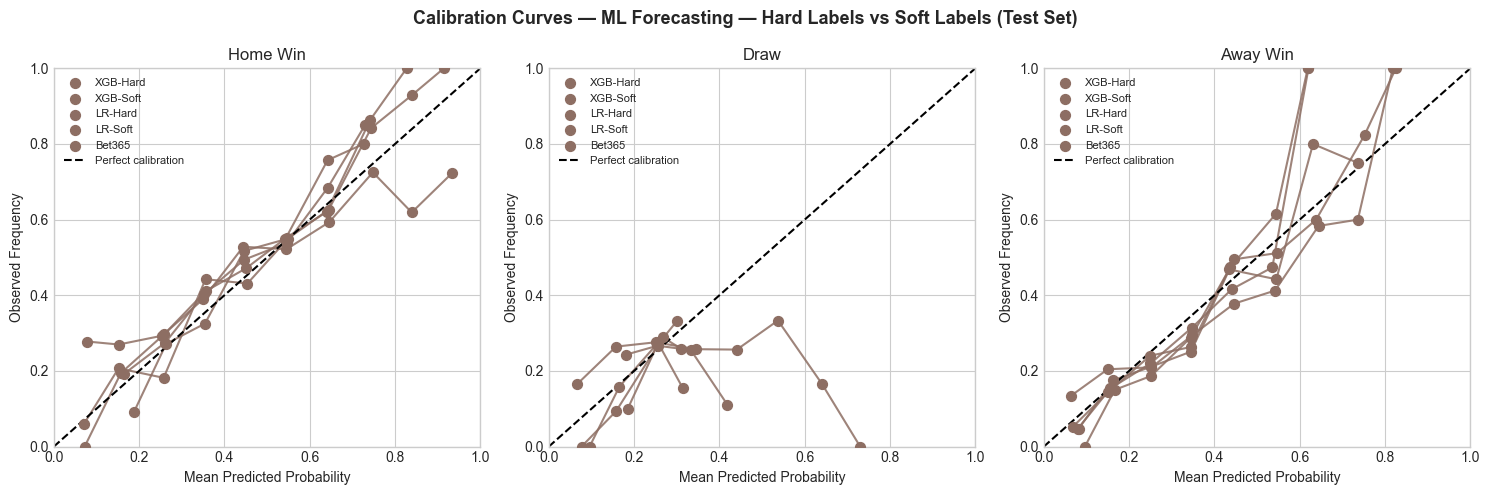

Saved → /home/max/drive/projects/4_forecasting-polynomial-multiplication/data-analysis/supplementary-material/ml_forecasting/figures/calibration_curves.png


In [17]:
# ── Calibration curves ────────────────────────────────────────────────────────
fig = plot_calibration_curves(
    models_dict,
    title="ML Forecasting — Hard Labels vs Soft Labels (Test Set)",
    save_path=FIGURES_DIR / "calibration_curves.png",
)
plt.show()
print(f"Saved → {FIGURES_DIR / 'calibration_curves.png'}")

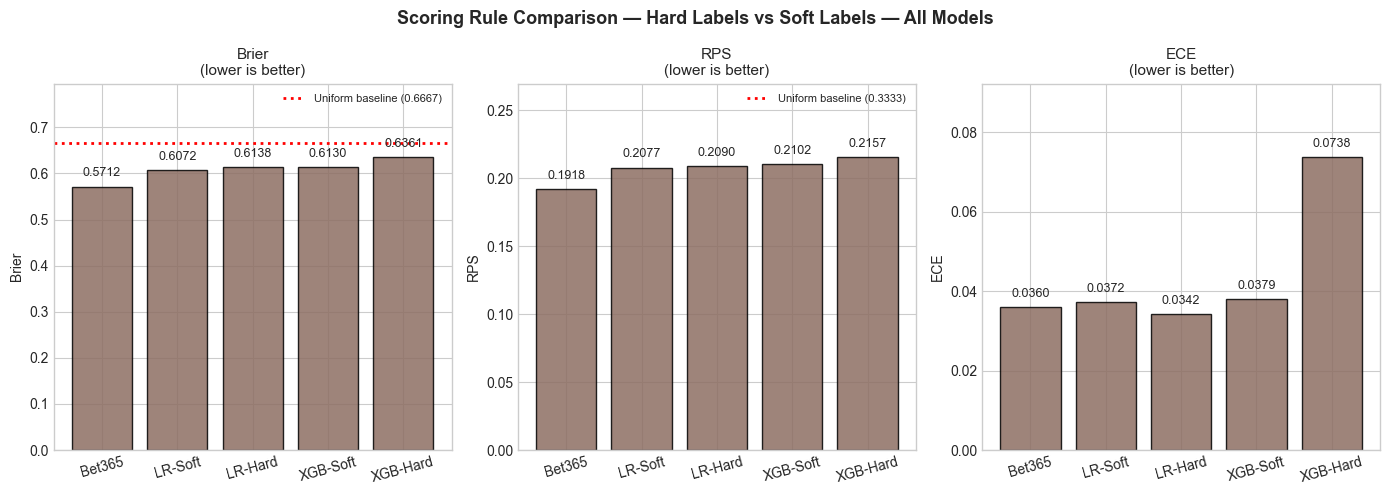

Saved → /home/max/drive/projects/4_forecasting-polynomial-multiplication/data-analysis/supplementary-material/ml_forecasting/figures/scoring_comparison.png


In [18]:
# ── Scoring comparison bar chart ──────────────────────────────────────────────
fig = plot_scoring_comparison(
    scores_df,
    title="Hard Labels vs Soft Labels — All Models",
    save_path=FIGURES_DIR / "scoring_comparison.png",
)
plt.show()
print(f"Saved → {FIGURES_DIR / 'scoring_comparison.png'}")

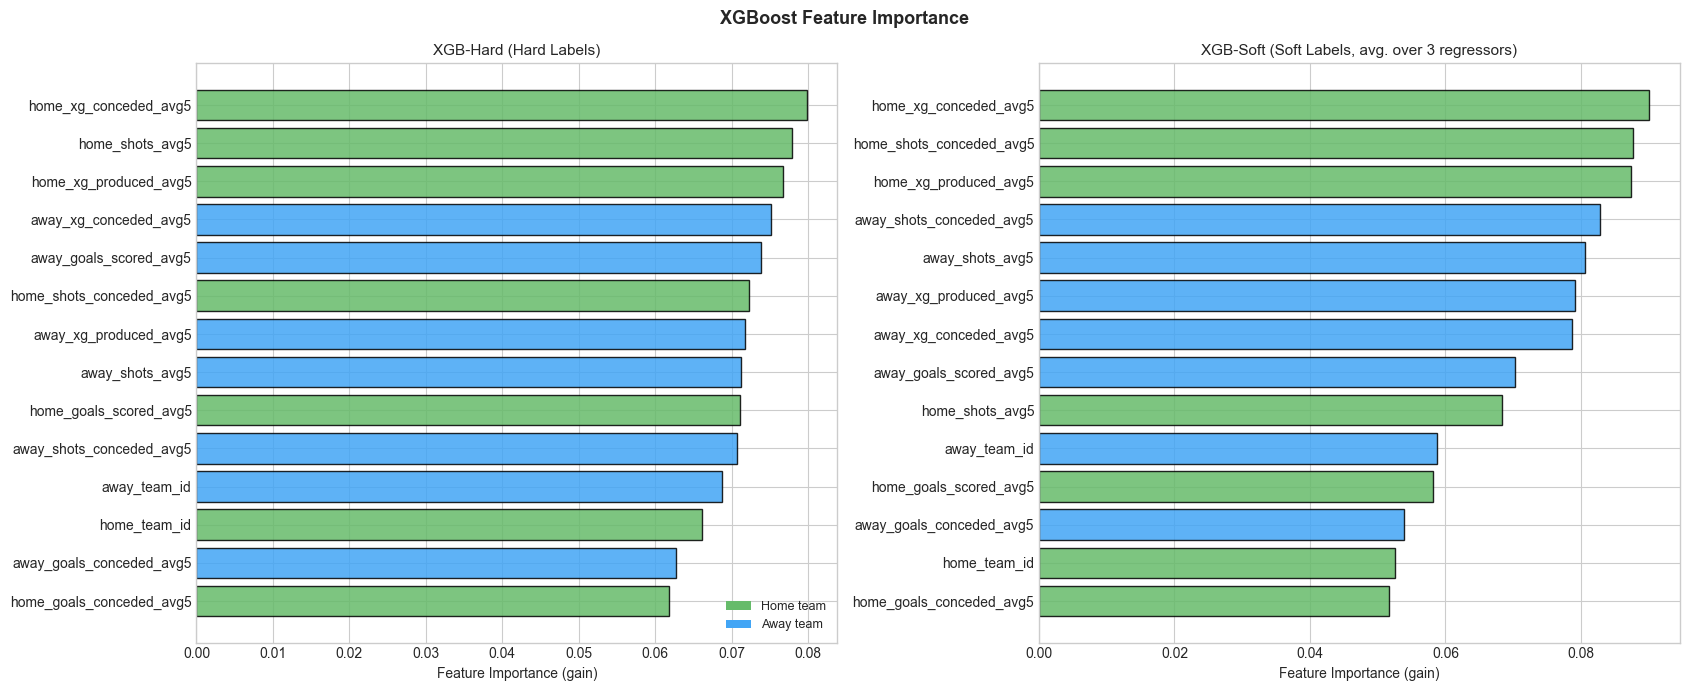

Saved → /home/max/drive/projects/4_forecasting-polynomial-multiplication/data-analysis/supplementary-material/ml_forecasting/figures/feature_importance.png


In [19]:
# ── XGBoost feature importance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Importance for hard-label model (single model, gain-based)
hard_imp = xgb_hard.feature_importances_
# Importance for soft-label model (average across 3 outcome regressors)
soft_imp = np.mean([m.feature_importances_ for m in xgb_soft_models], axis=0)

for ax, imp, title in zip(
    axes,
    [hard_imp, soft_imp],
    ["XGB-Hard (Hard Labels)", "XGB-Soft (Soft Labels, avg. over 3 regressors)"],
):
    idx = np.argsort(imp)
    colors = ["#66BB6A" if "home_" in FEATURE_COLS[i] or FEATURE_COLS[i] == "home_team_id"
              else "#42A5F5" if "away_" in FEATURE_COLS[i] or FEATURE_COLS[i] == "away_team_id"
              else "#EF5350"
              for i in idx]
    ax.barh(
        np.array(FEATURE_COLS)[idx], imp[idx],
        color=colors, edgecolor="black", alpha=0.85,
    )
    ax.set_xlabel("Feature Importance (gain)")
    ax.set_title(title, fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#66BB6A", label="Home team"),
    Patch(facecolor="#42A5F5", label="Away team"),
]
axes[0].legend(handles=legend_handles, fontsize=9, loc="lower right")

plt.suptitle("XGBoost Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'feature_importance.png'}")

## 8. Save Predictions

In [20]:
# Save combined predictions parquet
all_preds = []
for name, df in models_dict.items():
    df_out = df.copy()
    df_out["model"] = name
    all_preds.append(df_out)
combined = pd.concat(all_preds, ignore_index=True)
out_path = OUTPUT_DIR / "ml_predictions.parquet"
combined.to_parquet(out_path, index=False)
print(f"Saved {len(combined)} rows to {out_path}")
print(f"Columns: {list(combined.columns)}")

Saved 4554 rows to /home/max/drive/projects/4_forecasting-polynomial-multiplication/data-analysis/supplementary-material/ml_forecasting/output/ml_predictions.parquet
Columns: ['match_id', 'actual_outcome', 'p_home_win', 'p_draw', 'p_away_win', 'model']


## 9. Summary & Interpretation

### Hard Labels vs. Soft Labels

The core comparison is whether using **Poisson-Binomial probability estimates as training
targets** (soft labels) improves model accuracy over training on **binary outcomes**
(hard labels).

**Why soft labels might help:**
- Binary outcomes are noisy: a team that dominated a match may have lost. The PB probability
  (e.g., 0.72 home win) reflects the quality of performance better than a 0/1 label.
- Soft labels convey more information per training example (the full probability
  distribution rather than just which outcome occurred).
- This is conceptually analogous to *knowledge distillation*: the PB model serves as
  a "teacher" that distils richer information into the ML training signal.

**Benchmark context:**
- **Bet365** pre-match odds represent informed market forecasts and serve as an upper
  bound for what pre-match models can realistically achieve.
- Our ML models use only team identity + rolling-window features (no line-up, tactical,
  or injury information), so some gap vs. betting markets is expected.

**Feature importance:**
- Team identity features typically dominate in the first half of the season when rolling
  history is limited.
- Rolling xG features tend to gain importance as the season progresses, because they
  capture recent in-form performance beyond team quality.

### Limitations
- Single season (2015/16) across five leagues — limited generalisation.
- Features are simple rolling averages; richer features (home/away splits, opponent strength,
  momentum) would likely improve all models.
- Hyper-parameters were not tuned via cross-validation to avoid overfitting to the test split.